In [1]:
%pip install pandas matplotlib seaborn numpy scipy statsmodels


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# **Pipeline de Inferência Estatística Clássica**

Em pesquisas científicas, é comum encontrar termos como **nível de significância**, **t-tests** e **valores-p**. Esses experimentos são desenhados com o objetivo de **rejeitar ou aceitar hipóteses** sobre uma população a partir de uma amostra representativa.

**O processo segue, de forma geral, 4 etapas:**

1. **Formulação da hipótese**, ex.: "O remédio A é mais eficaz que o remédio B".
2. **Desenho do experimento**, ex.: um teste A/B para testar a hipótese formulada.
3. **Coleta dos dados**, execução do experimento e registro dos resultados.
4. **Análise e inferência**, aplicação de testes estatísticos (como t-test, cálculo de valor-p, comparação com o nível de significância) para concluir se há evidência suficiente para rejeitar ou não a hipótese.

<img src="images_statistics/classical_pipeline.png" width="600" style="display:block; margin:auto;">

## **Teste A/B**

Experimento com dois grupos (tratamentos, produtos, designs, etc.) em que variamos algo em um dos grupos e investigamos o resultado dessa variação. Consiste em: dividir os sujeitos em dois grupos (ex.: dividir o tráfego de um site entre duas versões de interface, gerando um grupo que usa a versão A e outro que usa a versão B), definir uma métrica de interesse (ex.: cliques), calcular essa métrica para cada grupo e aplicar um teste estatístico (geralmente teste-t) para verificar a significância da diferença observada. O grupo A deve ser o **controle**, e a única diferença entre A e B deve ser exatamente a característica que se quer investigar.

### **Por que usar um grupo controle?**

Poderíamos, em vez disso, testar apenas a nova característica em um único grupo e comparar com resultados históricos (de antes da mudança). O problema é que não há garantia de que todas as outras condições eram idênticas entre os dois momentos. Com um grupo controle rodando **simultaneamente**, garantimos que todas as condições são as mesmas em ambos os grupos, exceto a característica estudada.

### **Blinding / Double Blinding**

- **Blinding:** os sujeitos não sabem se estão recebendo a característica A ou B, o simples fato de saber pode influenciar o resultado (efeito placebo, por exemplo).
- **Double Blinding:** nem os sujeitos nem os pesquisadores que avaliam os resultados sabem qual grupo é qual, adicionando uma camada extra de segurança contra viés.

Essas técnicas só são aplicáveis quando a característica não é obviamente identificável pelo sujeito ou pesquisador.

### **Teste A/B em Contexto Web**

Muito usado para testar características de design, preços, etc., em que o sujeito é um usuário web e as métricas de interesse costumam ser cliques, tempo de tela e número de compras. A métrica de avaliação deve ser definida **antes** do experimento. Escolher a métrica depois de ver os resultados leva a viés de pesquisa (selecionar a métrica que favorece o resultado desejado).

### **Por que não testes A/B/C/D...?**

O teste A/B pode ser estendido para múltiplas variantes (C, D, E...), mas cada variante adicional exige mais sujeitos, e isso tem custo. Exemplo: em um teste com 4 variantes, sabendo que A é boa e D é muito ruim, ainda seria necessário enviar 25% do tráfego para a variante ruim só para provar estatisticamente a diferença, o que pode significar perda real de receita durante o experimento.

Isso reflete uma diferença de objetivo:
- **Estatística clássica:** foca em **significância**, "Podemos afirmar com 95% de confiança que A é diferente de B?"
- **Ciência de dados aplicada:** foca em **recompensa*, "Qual variante maximiza minha receita agora?"

Algoritmos como o **multi-armed bandit** resolvem esse trade-off desviando o tráfego dinamicamente para os grupos que estão performando melhor, reduzindo o custo de explorar variantes ruins.

## **Testes de Hipótese**

Também chamados de **testes de significância**, servem para quantificar se um efeito observado em um experimento é real ou pode ser explicado apenas pela variabilidade aleatória (o acaso). Isso é feito verificando o quão raro seria o valor observado do efeito sob uma distribuição de referência que assume que o resultado ocorreu totalmente ao acaso, a **distribuição nula**.

### **Hipótese Nula (H₀)**

É a suposição de que a diferença observada é apenas coincidência (ausência de efeito real). Se a hipótese alternativa é "B é maior/melhor que A", a hipótese nula é "B é igual ou pior que A".

### **Hipótese Alternativa (H₁)**

Contradiz a hipótese nula e é definida em função dela:

| Hipótese Nula (H₀) | Hipótese Alternativa (H₁) |
|---|---|
| Não há diferença entre as médias de A e B | A média de B é diferente da de A (maior ou menor) |
| A ≥ B | A < B |
| B não é X% maior que A | B é X% maior que A |

O objetivo do teste é verificar se há evidência suficiente nos dados para **rejeitar** a hipótese nula em favor da alternativa, ou seja, geralmente é a hipótese alternativa que buscamos sustentar com o experimento.

### **Unidirecional (One-tail) vs. Bidirecional (Two-tail)**

- **Unidirecional:** quando o interesse é apenas em uma direção (B > A **ou** B < A), apenas uma cauda da distribuição nula é relevante, a direita (se testamos B > A) ou a esquerda (se testamos B < A).
- **Bidirecional:** quando o interesse é saber se A ≠ B, ambas as caudas importam, pois B pode ser maior (cauda direita) ou menor (cauda esquerda) que A sob a hipótese nula B = A.

### **Confiabilidade × Impacto**

O teste de hipótese **não** informa o tamanho do impacto (isso é papel da **magnitude do efeito**), ele informa apenas a confiabilidade de que o impacto não é zero. Achar que um p-valor muito pequeno significa uma mudança grande é um erro. Na verdade, ele só indica alta confiança de que a mudança existe (mesmo que seja pequena).

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import ipywidgets as widgets
from IPython.display import display

def plot_hypothesis(tipo_teste, impacto, confiabilidade):
    # Configurando o eixo X (o espectro de diferenças possíveis)
    x = np.linspace(-6, 6, 1000)
    
    # A variância diminui à medida que a confiabilidade (tamanho da amostra) aumenta
    # Simulamos isso matematicamente: desvio padrão inversamente proporcional à raiz da amostra
    std = 3 / np.sqrt(confiabilidade)
    
    # Gerando as Distribuições Nula (H0) e Alternativa (H1)
    y_h0 = norm.pdf(x, loc=0, scale=std)
    y_h1 = norm.pdf(x, loc=impacto, scale=std)
    
    plt.figure(figsize=(10, 6))
    
    # Plotando as curvas
    plt.plot(x, y_h0, label='H0 (Nula) - Efeito Zero', color='#011f4b', linewidth=2.5)
    plt.plot(x, y_h1, label=f'H1 (Alternativa) - Impacto Real: {impacto:.1f}', color='#2ab7ca', linewidth=2.5)
    
    # Definindo o nível de significância (Alpha = 5%)
    alpha = 0.05
    
    # Preenchendo as regiões críticas de acordo com o tipo de teste
    if tipo_teste == 'Bidirecional (A != B)':
        limite_inf = norm.ppf(alpha/2, loc=0, scale=std)
        limite_sup = norm.ppf(1 - alpha/2, loc=0, scale=std)
        
        plt.fill_between(x, y_h0, where=(x <= limite_inf), color='#fe4a90', alpha=0.4, label='Região Crítica (2.5% cada lado)')
        plt.fill_between(x, y_h0, where=(x >= limite_sup), color='#fe4a90', alpha=0.4)
        plt.axvline(limite_inf, color='#fe4a90', linestyle='--', alpha=0.8)
        plt.axvline(limite_sup, color='#fe4a90', linestyle='--', alpha=0.8)
        
    elif tipo_teste == 'Unidirecional à Direita (B > A)':
        limite_sup = norm.ppf(1 - alpha, loc=0, scale=std)
        
        plt.fill_between(x, y_h0, where=(x >= limite_sup), color='#fe4a90', alpha=0.4, label='Região Crítica (5%)')
        plt.axvline(limite_sup, color='#fe4a90', linestyle='--', alpha=0.8)
        
    elif tipo_teste == 'Unidirecional à Esquerda (B < A)':
        limite_inf = norm.ppf(alpha, loc=0, scale=std)
        
        plt.fill_between(x, y_h0, where=(x <= limite_inf), color='#fe4a90', alpha=0.4, label='Região Crítica (5%)')
        plt.axvline(limite_inf, color='#fe4a90', linestyle='--', alpha=0.8)

    # Configurações visuais do gráfico
    plt.title('Simulador de Teste de Hipóteses', fontsize=16, fontweight='bold')
    plt.xlabel('Diferença Observada', fontsize=12)
    plt.ylabel('Densidade', fontsize=12)
    plt.legend(loc='upper right', fontsize=10)
    plt.grid(True, linestyle=':', alpha=0.7)
    
    # Painel explicativo dinâmico
    texto_explicativo = (
        f"Impacto (Distância H0-H1): {'Alto' if abs(impacto) > 2 else 'Médio' if abs(impacto) > 0.8 else 'Baixo'}\n"
        f"Confiabilidade (Amostra): {'Alta' if confiabilidade > 60 else 'Média' if confiabilidade > 30 else 'Baixa'}"
    )
    plt.text(-5.8, max(y_h0) * 0.85, texto_explicativo, 
             bbox=dict(facecolor='white', alpha=0.9, edgecolor='#ccc', boxstyle='round,pad=0.5'), fontsize=10)
    
    plt.ylim(0, max(y_h0) * 1.2)
    plt.tight_layout()
    plt.show()

# Montando a Interface com os Sliders e Dropdowns
interface = widgets.interactive(
    plot_hypothesis,
    tipo_teste=widgets.Dropdown(
        options=['Bidirecional (A != B)', 'Unidirecional à Direita (B > A)', 'Unidirecional à Esquerda (B < A)'],
        value='Bidirecional (A != B)',
        description='Tipo de Teste:',
        style={'description_width': 'initial'}
    ),
    impacto=widgets.FloatSlider(
        value=1.5, min=-4.0, max=4.0, step=0.1,
        description='Impacto (Efeito):',
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='500px')
    ),
    confiabilidade=widgets.IntSlider(
        value=20, min=5, max=100, step=5,
        description='Confiabilidade (Amostra):',
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='500px')
    )
)

display(interface)

interactive(children=(Dropdown(description='Tipo de Teste:', options=('Bidirecional (A != B)', 'Unidirecional …

### **Teste de Hipótese Paramétrico**

Assume que a estatística observada segue aproximadamente uma **distribuição de referência teórica** conhecida (Normal, t-Student, F, etc.). A escolha da distribuição depende do que se está testando: médias costumam usar Z-score ou t-Student, enquanto variância costuma usar F-score.

**Como funciona:** calcula-se uma estatística (ex.: t-score) a partir do efeito observado nos dados, e então verifica-se o quão rara essa estatística seria na distribuição de referência que representa a hipótese nula.

**Limitação:** esses testes sofrem quando suas premissas são violadas. Por exemplo, t-test e z-test assumem que a distribuição amostral da estatística testada é aproximadamente normal. Isso costuma ser válido para médias (Teorema Central do Limite), mas pode não valer para outras estatísticas, violando a premissa do método.

### **Teste de Hipótese Não Paramétrico**

Não assume nenhuma distribuição de referência teórica. Geralmente utiliza distribuições **empíricas**, construídas via **bootstrap** ou **ranks** (ordem dos dados). Por fazer menos suposições, costuma ser mais robusto em distribuições incomuns ou fora do padrão.

### **Teste Pareado**

Testes paramétricos comuns (como o t-test) geralmente assumem **independência entre os grupos**, isto é, que os indivíduos do grupo controle e do grupo testado não têm relação alguma entre si. Porém, isso nem sempre é verdade: em muitos experimentos a **mesma amostra** é medida duas vezes, variando algo (ex.: um remédio). Nesse caso, usa-se o **teste pareado**: formam-se pares do tipo (resultado_indivíduo₁_condição1, resultado_indivíduo₁_condição2), calcula-se a diferença de cada par (a evolução daquele indivíduo) e verifica-se se a **média dessas diferenças** é estatisticamente diferente de 0, ou seja, testa-se o quão distante essa média está de 0 em relação a uma distribuição de referência.

**Vantagem:** por usar os mesmos indivíduos nas duas condições, o teste pareado é robusto contra a variação genética/individual entre sujeitos independentes, já que as características intrínsecas de cada pessoa permanecem as mesmas em ambas as medições.

### **Permutation Test**

Método **não paramétrico** para testes de hipótese: em vez de assumir que a estatística segue uma distribuição conhecida (Normal, t, etc.), calcula-se a distribuição de referência via **reamostragem**, e essa distribuição empírica é usada para aceitar ou rejeitar a hipótese nula.

**Algoritmo:**

0. Calcule e armazene a métrica original do teste (usando os grupos reais do experimento).
1. Junte os resultados de todos os grupos (A, B, C...) em um único conjunto, isso representa a hipótese nula de que todos os grupos são equivalentes.
2. Embaralhe (shuffle) esse conjunto combinado.
3. Retire, **sem reposição**, uma amostra do tamanho de cada grupo original (ex.: se A tem 3 elementos e B tem 2, tire 3 elementos para formar o "novo A" e os 2 restantes formam o "novo B").
4. Calcule a métrica do teste (ex.: diferença entre médias/proporções) para os novos grupos e armazene o resultado.
5. Repita os passos 2-4 *I* vezes (número de iterações), gerando uma **distribuição de métricas de permutação**.
6. Compare a métrica original com essa distribuição:
   - Se estiver próxima do centro (alta densidade), a diferença observada provavelmente é coincidência, não é rara o suficiente para rejeitar H₀.
   - Se estiver na cauda da distribuição, o resultado é estatisticamente significante (baixa probabilidade de ocorrer ao acaso).

### **Variações**

- **Permutação Exaustiva (ou Exata):** em vez de embaralhar repetidamente de forma aleatória, calculam-se **todas** as combinações possíveis dos grupos. Garante exatidão, mas o número de combinações cresce exponencialmente, só é viável para datasets muito pequenos.

- **Permutação Bootstrap:** no passo 3, a amostragem passa a ser **com reposição** (sorteia-se um elemento, anota-se o valor, e ele volta ao conjunto antes do próximo sorteio). Enquanto a permutação comum testa apenas o erro de **alocação/balanceamento** dos grupos, a versão bootstrap também simula a possibilidade de que **a própria amostra coletada não represente perfeitamente a população real**, capturando assim uma fonte adicional de incerteza.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

web_sessions = pd.read_csv("data_statistics/web_page_data.csv")

web_sessions.head()

,Page,Time
0,Page A,0.21
1,Page B,2.53
2,Page A,0.35
3,Page B,0.71
4,Page A,0.67


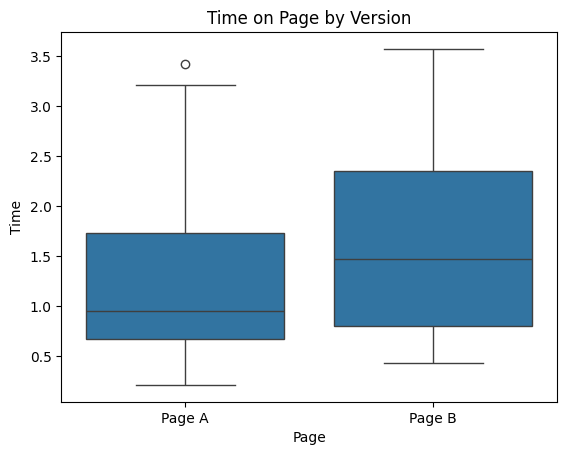

In [4]:
ax = sns.boxplot(x="Page", y="Time", data=web_sessions)
ax.set_title("Time on Page by Version")
plt.show()

# Parece muito que B tem um tempo médio maior que A, mas vamos testar isso com um teste de permutação.

Observed Difference: 0.3567
P-value: 0.1361


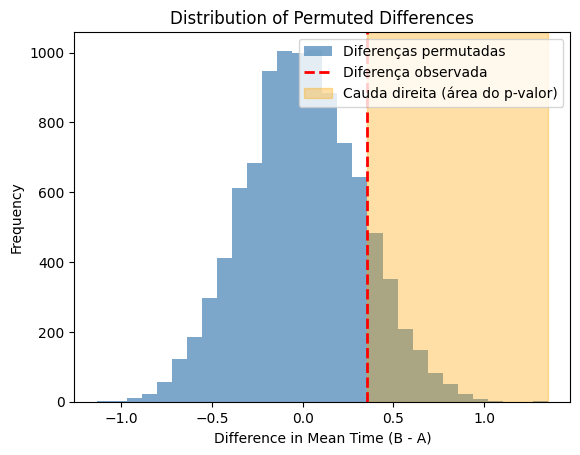

In [5]:
# permutation test
page_labels = web_sessions["Page"].astype(str).str.strip()
is_a = page_labels.str.fullmatch(r"Page A", case=False, na=False)
is_b = page_labels.str.fullmatch(r"Page B", case=False, na=False)

page_a = web_sessions.loc[is_a, "Time"]
page_b = web_sessions.loc[is_b, "Time"]

observed_diff = page_b.mean() - page_a.mean()  # diferença observada entre as médias

combined = np.concatenate([page_a, page_b])  # combina os dados das duas páginas
num_iter = 10000

permuted_diffs = np.empty(num_iter) # distribuição das diferenças permutadas
for i in range(num_iter):
    shuffled = np.random.permutation(combined)  # embaralha sem alterar o array original
    permuted_a = shuffled[:len(page_a)]  # nova amostra para a página A
    permuted_b = shuffled[len(page_a):]  # nova amostra para a página B
    permuted_diffs[i] = permuted_b.mean() - permuted_a.mean()  # diferença entre as médias dos grupos permutados


# aqui temos a probabilidade da diferença observada ser tão extrema quanto a que encontramos, assumindo que a hipótese nula é verdadeira (ou seja, que não há diferença real entre as páginas A e B).
p_value = np.mean(permuted_diffs >= observed_diff)  # p-valor para a hipótese alternativa de que B é maior que A
print(f"Observed Difference: {observed_diff:.4f}")
print(f"P-value: {p_value:.4f}")

# histograma das diferenças permutadas
plt.hist(permuted_diffs, bins=30, alpha=0.7, color='steelblue', label='Diferenças permutadas')
plt.axvline(observed_diff, color='red', linestyle='dashed', linewidth=2, label='Diferença observada')
plt.axvspan(observed_diff, permuted_diffs.max(), color='orange', alpha=0.35, label='Cauda direita (área do p-valor)')
plt.title('Distribution of Permuted Differences')
plt.xlabel('Difference in Mean Time (B - A)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

### **T-Test e Z-Test Não Pareados**

![image.png](images_statistics/padrao_media.png)

**Z-test vs. T-test — qual a diferença real?**:

- **Z-test:** usado quando σ² é conhecida (raro na prática), ou, na prática, como aproximação quando a amostra é grande (n ≥ 30), já que nesse caso a distribuição t se aproxima muito da normal.
- **T-test:** usado quando σ² é **desconhecida** e precisa ser estimada a partir da amostra (s²), o caso mais comum. Funciona para qualquer tamanho de amostra.

Na prática, o **t-test é o "default" mais seguro**: ele incorpora a incerteza extra de estimar a variância a partir da amostra (por isso usa a distribuição t, com caudas mais pesadas que a normal para amostras pequenas), e à medida que o tamanho da amostra cresce, a distribuição t converge para a normal, ou seja, o t-test "vira" um z-test automaticamente para amostras grandes. Por isso, usar t-test mesmo com n ≥ 30 nunca está errado. Tanto os scores t e z representam a distancia de um valor para o centro escolhido da distribuicao que geralmente é a media mas em testes é a hipotese nula.

$$t = \frac{(\bar{x}_B - \bar{x}_A) - 0}{\sqrt{\frac{s_A^2}{n_A} + \frac{s_B^2}{n_B}}}$$

**Onde:**
* $(\bar{x}_B - \bar{x}_A)$: diferença observada (sinal).
* $0$: valor da Hipótese Nula ($H_0$).
* $\sqrt{\frac{s_A^2}{n_A} + \frac{s_B^2}{n_B}}$: Erro Padrão combinado (ruído).

Essa fórmula (com variâncias separadas $s_A^2/n_A + s_B^2/n_B$) é o **teste t de Welch**, usado quando não assumimos variâncias iguais entre os grupos. A fórmula "$n_A + n_B - 2$" vale apenas para o **teste t pooled/Student clássico**, que assume variâncias iguais entre os grupos, uma premissa mais forte e menos usada na prática, já que o teste de Welch é considerado mais robusto e é o padrão adotado por padrão em softwares como R e Python (scipy).

"O teste começa assumindo que a distribuição da diferença entre os 2 grupos independentes segue uma distribuição t centrada em 0 (nossa hipótese nula: a diferença entre as médias dos grupos é 0). Depois calculamos o t-score com a diferença observada e verificamos o quão raro esse valor é sob essa distribuição de referência." Temos a garantiade normalidade pois as medias amostrais dos 2 grupos vieram de somas e devido ao TCL a distribuicao dessas medias é proxima da normal, a subtracao dessas duas medias também será proximo da normal ... se o numerador é normal, então dividir essa variável normal por uma estimativa do seu erro padrão gera uma variável que segue a distribuição t (ou normal padrão Z, se o erro padrão fosse conhecido com certeza). É exatamente essa propriedade que permite comparar o t calculado com uma tabela/distribuição t e extrair um p-valor.

Se a diferença não fosse normal, o t calculado não seguiria a distribuição t, e comparar com a tabela t daria um p-valor errado (a "régua" usada para medir o quão raro é o resultado estaria calibrada errado).

### **T-Test Pareado**

A grande diferença na mecânica é que não calculamos a média do Grupo A e do Grupo B separadamente para compará-las. Em vez disso, calculamos a evolução individual (Diferença = Depois − Antes) para cada sujeito da amostra. O teste passa a olhar apenas para essa coluna de evoluções. A hipótese nula continua fixada em zero: assumimos que a média dessas evoluções é 0 (ou seja, nenhum impacto real). A partir daí, a lógica é igual à do teste não pareado: verificamos a quantos erros padrões a evolução média observada está de zero na distribuição t.

$$t = \frac{\bar{d} - 0}{\frac{s_d}{\sqrt{n}}}$$

**Onde:**
* $\bar{d}$: média aritmética das evoluções/diferenças (sinal).
* $0$: valor da Hipótese Nula ($H_0$).
* $\frac{s_d}{\sqrt{n}}$: Erro Padrão das diferenças (ruído).


In [6]:
# teste de hipotese parametrico agora

t_stat, p_value_ttest = stats.ttest_ind(page_b, page_a, alternative='greater')
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value (t-test): {p_value_ttest:.4f}")

T-statistic: 1.1237
P-value (t-test): 0.1345


### **Significância Estatística**

Significância estatística é a forma como estatísticos medem se o resultado de um experimento ou estudo é mais incomum/extremo do que a pura variabilidade aleatória (acaso) poderia gerar sozinha.

### **Valor-p**

É a probabilidade de, **sob a hipótese nula** (assumindo que ela é verdadeira), obter resultados tão extremos ou mais extremos que os observados. Geometricamente, é a área (probabilidade acumulada) na cauda da distribuição da hipótese nula, a partir do valor observado:

- **Teste unilateral:** área de uma única cauda.
- **Teste bilateral:** o dobro dessa área, já que ambas as caudas (efeito maior *ou* menor) contam.

<img src="images_statistics/valorp.png" width="600" style="display:block; margin:auto;">

### **Alpha (α)**

É o limiar de probabilidade escolhido para decidir o que é "apenas acaso" e o que é "evento raro o suficiente para ser significante". Ex.: com α = 5%, se o p-valor for **menor** que 5%, o resultado é considerado estatisticamente significante; caso contrário, não é.

### **P-Hacking**

Se você testar 20 variáveis diferentes contra um mesmo resultado, é estatisticamente provável que ao menos uma delas tenha p-valor < 0,05 apenas por acaso. O problema surge quando o pesquisador publica só essa variável "vencedora" e ignora as outras 19 que falharam — gerando ciência de baixa qualidade e resultados difíceis de replicar.

### **Significância Prática × Estatística**

Conforme o tamanho da amostra cresce, o erro padrão diminui, e qualquer diferença mínima (ex.: um aumento de 0,0001% na taxa de cliques) pode se tornar "estatisticamente significante", já que o teste ganha poder suficiente para provar que aquele valor minúsculo não foi acaso. Mas significância estatística **não implica** relevância prática: se implementar a mudança custa R$ 10.000, pode ser necessário milhões de transações só para "empatar" o investimento.

*(Por que isso acontece: o p-valor é inversamente proporcional às estatísticas de teste como t, z ou F, e essas estatísticas são inversamente proporcionais ao erro padrão. Como o erro padrão diminui com o aumento da amostra, a estatística do teste cresce, e o p-valor consequentemente cai, mesmo para efeitos praticamente irrelevantes.)*

### **Erros do Tipo I e Tipo II**

- **Tipo I (falso positivo):** você conclui que o efeito é real, mas na verdade ele ocorreu por acaso.
- **Tipo II (falso negativo):** você conclui que o efeito foi acaso, mas na verdade ele é real (pode ser causado por um tamanho de amostra insuficiente, uma amostra maior poderia revelar o efeito).

A função principal do teste de hipótese é evitar ser enganado pela sorte, por isso o foco principal é **minimizar o erro do Tipo I**.

### **Para Data Science**

Para um Data Scientist, o p-valor é uma **medida de evidência**, não uma prova definitiva. Ele ajuda a responder: "Vale a pena investir tempo analisando isso?" Se o p-valor for alto, provavelmente não. Se for baixo, o próximo passo é avaliar o **ROI** para tomar a decisão final.

**ROI (Retorno sobre Investimento):**

$$
\text{ROI} = \frac{\text{Ganho do Investimento} - \text{Custo do Investimento}}{\text{Custo do Investimento}}
$$

$$
\text{ROI (\%)} = \frac{\text{Ganho} - \text{Custo}}{\text{Custo}} \times 100
$$

O ROI é medido em unidades do "investimento inicial", ou seja, quanto se ganha em relação a quanto foi investido.

Taxa de conversão A: 0.8425%  (200/23739)
Taxa de conversão B: 0.8057%  (182/22588)

Diferença observada (B - A): -0.000368

P-value (permutação): 0.6797


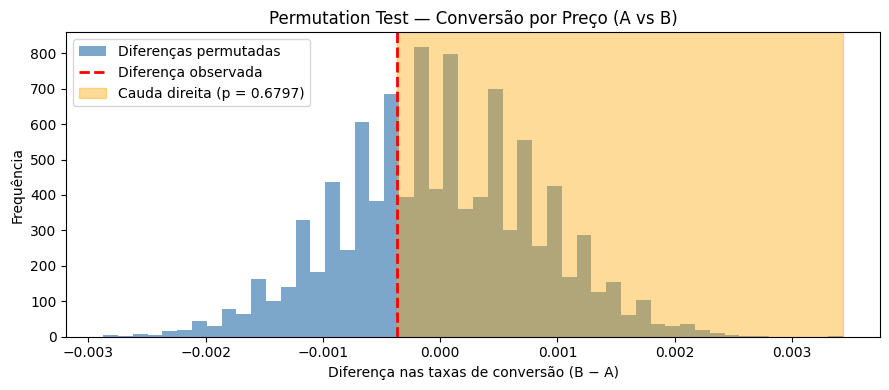


── Z-test para proporções (aproximação binomial) ──
Proporção pooled : 0.008246
Erro padrão (SE) : 0.000841
Z-score          : -0.4373
P-value (Z-test) : 0.6691

alpha = 0.05 → Falhamos em rejeitar H0 → diferença pode ser acaso.


In [7]:
conversions_a,  no_conv_a  = 200,  23_539   # preco A
conversions_b,  no_conv_b  = 182,  22_406   # preco B

group_a = np.array([1] * conversions_a  + [0] * no_conv_a,  dtype=np.float64)
group_b = np.array([1] * conversions_b  + [0] * no_conv_b,  dtype=np.float64)

n_a, n_b = len(group_a), len(group_b)
rate_a,  rate_b  = group_a.mean(), group_b.mean()

print(f"Taxa de conversão A: {rate_a:.4%}  ({conversions_a}/{n_a})")
print(f"Taxa de conversão B: {rate_b:.4%}  ({conversions_b}/{n_b})")

observed_diff_bin = rate_b - rate_a
print(f"\nDiferença observada (B - A): {observed_diff_bin:.6f}")

# ── Teste de Permutação ────────────────────────────────────────────────────────
combined_bin = np.concatenate([group_a, group_b])
num_iter_bin = 10_000

rng = np.random.default_rng(seed=42)
perm_diffs_bin = np.empty(num_iter_bin)

for i in range(num_iter_bin):
    shuffled = rng.permutation(combined_bin)
    perm_a = shuffled[:n_a]
    perm_b = shuffled[n_a:]
    perm_diffs_bin[i] = perm_b.mean() - perm_a.mean()

# teste unilateral: será que B > A?
p_value_perm = np.mean(perm_diffs_bin >= observed_diff_bin)
print(f"\nP-value (permutação): {p_value_perm:.4f}")


plt.figure(figsize=(9, 4))
plt.hist(perm_diffs_bin, bins=50, alpha=0.7, color='steelblue', label='Diferenças permutadas')
plt.axvline(observed_diff_bin, color='red', linestyle='dashed', linewidth=2, label='Diferença observada')
plt.axvspan(observed_diff_bin, perm_diffs_bin.max(), color='orange', alpha=0.4,
            label=f'Cauda direita (p = {p_value_perm:.4f})')
plt.title('Permutation Test — Conversão por Preço (A vs B)')
plt.xlabel('Diferença nas taxas de conversão (B − A)')
plt.ylabel('Frequência')
plt.legend()
plt.tight_layout()
plt.show()

# ── Aproximação pela Distribuição Binomial (Z-test para proporções) ────────────
# Sob H0: p_a = p_b = p_pooled → a diferença de proporções segue N(0, SE²)
# onde SE² vem da variância de Bernoulli: p*(1-p) * (1/n_a + 1/n_b)
from scipy.stats import norm

p_pooled_bin = (conversions_a + conversions_b) / (n_a + n_b)
se_bin = np.sqrt(p_pooled_bin * (1 - p_pooled_bin) * (1/n_a + 1/n_b))

z_score_bin = observed_diff_bin / se_bin
p_value_z   = 1 - norm.cdf(z_score_bin)   # unilateral (B > A)

print(f"\n── Z-test para proporções (aproximação binomial) ──")
print(f"Proporção pooled : {p_pooled_bin:.6f}")
print(f"Erro padrão (SE) : {se_bin:.6f}")
print(f"Z-score          : {z_score_bin:.4f}")
print(f"P-value (Z-test) : {p_value_z:.4f}")

alfa = 0.05
resultado = "Rejeitamos H0 → diferença estatisticamente significante!" if p_value_z < alfa \
            else "Falhamos em rejeitar H0 → diferença pode ser acaso."
print(f"\nalpha = {alfa} → {resultado}")


### **Problema de Múltiplos Testes de Hipótese nos Mesmos Dados**

O ditado "se você torturar os dados o suficiente, eles começam a falar" se aplica aqui. Ao escolher α = 0,05 em um teste, dizemos que se a probabilidade de um evento tão raro quanto o observado (sob a hipótese nula), o **p-valor**, for menor que 5%, aceitamos a hipótese alternativa. Isso significa assumir um risco de 5% de cometer o **Erro do Tipo I** (concluir que há efeito significativo quando, na verdade, é apenas ruído).

A probabilidade de **não** errar em um único teste é 95%. Ao rodar vários testes sobre os mesmos dados, a probabilidade de não errar em **nenhum** deles cai para $0{,}95^n$, que diminui rapidamente conforme *n* cresce, aproximando-se de zero.

**Como mitigar:**
- **Ajuste de Bonferroni:** divide o α pelo número de testes *n*. Para 20 testes, o novo limiar de p-valor seria 0,05/20 = 0,0025.

### Teste ANOVA

Quando, em vez de um teste A/B, temos **vários grupos** (A/B/C/D...) com variável de resposta contínua, o **ANOVA** (Analysis of Variance) é o padrão. Ele testa a hipótese nula de que as médias de todos os grupos são iguais, usando a **distribuição F** como referência.

**Por que não fazer vários t-tests?** Com 3 grupos (A, B, C), poderíamos rodar 3 testes-t (A vs B, B vs C, A vs C). Porém, pelo problema de múltiplos testes, cada um carrega risco de erro de 5% — ao fazer 3 testes, o risco total sobe para cerca de 14%. O ANOVA resolve isso testando todos os grupos simultaneamente em uma única análise, mantendo o erro global em 5%.

**Versão via reamostragem:**
1. Combine todos os dados em um único conjunto.
2. Embaralhe e retire, sem reposição, grupos dos mesmos tamanhos que os grupos originais.
3. Registre a média de cada um dos grupos reamostrados.
4. Registre a variância dessas médias.
5. Repita os passos 2-4 por *I* iterações.
6. Compare a variância observada (original) com a distribuição de variâncias obtida por reamostragem, calculando o valor-p a partir da proporção de vezes que a variância reamostrada excedeu a observada.

**Teste Omnibus:** o ANOVA é um teste *omnibus*, dá uma resposta geral. Um resultado significativo (p < 0,05) indica apenas que **pelo menos um** grupo é diferente dos demais, sem especificar qual. Para identificar quais pares diferem, é necessário um **teste post-hoc**, como o Tukey HSD.

**Two-Way ANOVA:** extensão do ANOVA (one-way) para analisar **2 fatores categóricos simultâneos** sobre uma variável de resposta contínua. Responde a três perguntas de uma vez:
- **Efeito do Fator A:** o primeiro fator influencia o resultado?
- **Efeito do Fator B:** o segundo fator influencia o resultado?
- **Interação (A × B):** o efeito de um fator depende do nível do outro?

*Exemplo:* testar o tempo de carregamento de um site com Fator 1 (Navegador: Chrome vs. Firefox) e Fator 2 (Região: Brasil vs. EUA). A Two-Way ANOVA revelaria se o tempo varia por navegador, por região, ou se há **interação** (ex.: Chrome é rápido no Brasil mas lento nos EUA).

### 

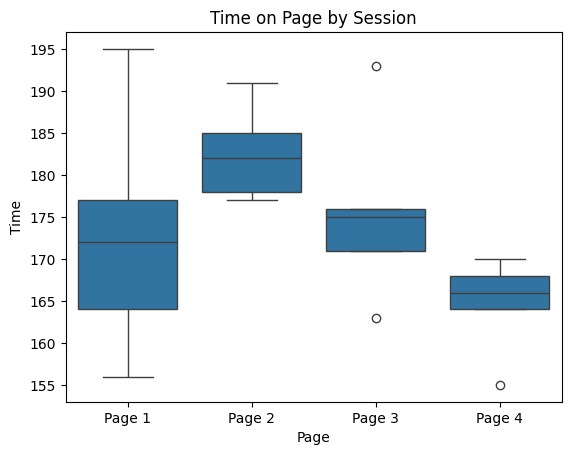

In [8]:
# ANOVA
four_sessions = pd.read_csv("data_statistics/four_sessions.csv")

sns.boxplot(x="Page", y="Time", data=four_sessions)
plt.title("Time on Page by Session")
plt.show()


In [9]:
# ANOVA usando reamostragem

variancia_observada = four_sessions.groupby("Page")["Time"].mean().var()
print(f"Variância observada entre as médias: {variancia_observada:.4f}")

num_iter_anova = 10000 # número de iterações para a permutação
permuted_variances = np.empty(num_iter_anova)
combined_anova = four_sessions["Time"].values # dados combinados para permutação
page_labels_anova = four_sessions["Page"].values # rótulos das páginas para permutação

for i in range(num_iter_anova):
    shuffled_labels = np.random.permutation(page_labels_anova) # embaralha os rótulos das páginas
    permuted_df = pd.DataFrame({"Page": shuffled_labels, "Time": combined_anova}) # cria um DataFrame com os rótulos embaralhados
    permuted_variances[i] = permuted_df.groupby("Page")["Time"].mean().var() # calcula a variância entre as médias para os dados permutados

p_value_anova = np.mean(permuted_variances >= variancia_observada)
print(f"P-value (ANOVA por permutação): {p_value_anova:.4f}")



Variância observada entre as médias: 55.4267
P-value (ANOVA por permutação): 0.0776


### **Estatística F**

Assim como o teste-t pode substituir o teste de permutação para dois grupos (teste A/B), o **ANOVA** utiliza a **distribuição F** como base para comparar múltiplos grupos.

A estatística F é definida como:

$$
F = \frac{\text{Variância entre os grupos}}{\text{Variância dentro dos grupos}}
$$

**Interpretação:** se F é baixo, a variação entre os grupos é próxima da variação dentro dos grupos, ou seja, não há diferença significativa entre eles. Se F é alto, a variação entre grupos é muito maior do que a esperada apenas pelo ruído interno de cada grupo, sugerindo diferença real entre as médias.

O valor da estatística F calculado é então comparado com a **distribuição F padrão** sob a hipótese nula (a suposição de que as médias de todos os grupos são iguais), permitindo calcular o p-valor do teste.

In [10]:
# ANOVA usando teste F tradicional
from scipy.stats import f_oneway
groups = [group["Time"].values for name, group in four_sessions.groupby("Page")]
f_stat, p_value_f = f_oneway(*groups)
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value (ANOVA F-test): {p_value_f:.4f}")

F-statistic: 2.7398
P-value (ANOVA F-test): 0.0776


### **Teste Qui-Quadrado**

Usado com dados de **contagem** para comparar a distribuição observada com a distribuição esperada. O uso mais comum é testar a **independência entre duas variáveis categóricas** a partir de uma tabela de contingência.

**Abordagem via reamostragem:**
1. Junte todos os dados em um único conjunto (combinando todas as classes das variáveis).
2. Embaralhe e retire, sem reposição, *N* amostras, uma para cada coluna/classe, respeitando o tamanho original de cada uma (*N* = número de colunas).
3. Calcule a estatística qui-quadrado sobre essa reamostragem e armazene o resultado.
4. Repita os passos 2-3 por *I* iterações.
5. Compare quantas vezes o qui-quadrado reamostrado superou o qui-quadrado observado, calculando o valor-p a partir dessa proporção.

**Quando usar:** ideal para cenários envolvendo frequências, contagens e categorias. Os casos mais comuns são:

- **Teste de Independência:** verificar se duas variáveis categóricas estão relacionadas, ex.: a cor do botão (Azul vs. Vermelho) influencia a conversão (Comprou vs. Não Comprou)?

- **Goodness of Fit (aderência a uma distribuição esperada):** comparar proporções observadas com proporções teóricas conhecidas, ex.: se a população brasileira é 52% mulheres e 48% homens, mas sua amostra coletada tem 70% de homens, o teste de aderência indica se essa diferença é apenas ruído amostral ou sinal de viés no processo de coleta.

- **Feature Selection:** verificar se uma variável categórica (ex.: "Cor Favorita") é independente da variável alvo (ex.: "Churn"). Se o p-valor for alto (sem evidência de associação), a variável tem pouco poder preditivo e pode ser removida do modelo, simplificando-o e reduzindo o risco de overfitting.

In [11]:
# Teste Qui-quadrado para independência
df_qui = pd.DataFrame({
    "Headline A": [14, 986],
    "Headline B": [8, 992],
    "Headline C": [12, 988]
}, index=["Click", "No-click"])

observed_chi2 = stats.chi2_contingency(df_qui)[0]

# "pool" de dados reais (34 uns e 2966 zeros)
total_clicks = df_qui.loc["Click"].sum()
total_no_clicks = df_qui.loc["No-click"].sum()
all_outcomes = np.array([1] * total_clicks + [0] * total_no_clicks)

# (1000, 1000, 1000)
group_sizes = df_qui.sum().values 

num_iter_chi2 = 10000
permuted_chi2 = np.empty(num_iter_chi2)

for i in range(num_iter_chi2):

    np.random.shuffle(all_outcomes)
    
    # reconstrói a tabela com os mesmos tamanhos de grupo originais
    start = 0
    new_counts = []
    for size in group_sizes:
        group_slice = all_outcomes[start : start + size]
        clicks = group_slice.sum()
        no_clicks = size - clicks
        new_counts.append([clicks, no_clicks])
        start += size
    
    permuted_table = np.array(new_counts).T
    permuted_chi2[i] = stats.chi2_contingency(permuted_table)[0]

p_value_chi2_perm = np.mean(permuted_chi2 >= observed_chi2)

print(f"Chi-squared (Observado): {observed_chi2:.4f}")
print(f"P-value (Permutação): {p_value_chi2_perm:.4f}")



Chi-squared (Observado): 1.6659
P-value (Permutação): 0.4964


### **Estatística Qui-Quadrado**

Seguindo a mesma lógica do t e do F, o χ² é a estatística usada na versão **paramétrica** do teste qui-quadrado. Ele representa a soma dos desvios ao quadrado entre a frequência observada e a esperada, **dividida pela própria frequência esperada** (e não por sua raiz):

$$
\chi^2 = \sum \frac{(O - E)^2}{E}
$$

Calcula-se então a área da cauda da distribuição χ² padrão sob a hipótese nula — de que as variáveis são independentes (ou, equivalentemente, que os dados seguem a distribuição esperada, já que independência implica que a distribuição esperada é a distribuição global). O **valor-p** é a probabilidade de observar uma estatística χ² tão grande ou maior do que a observada, sob essa hipótese nula.

In [12]:
from scipy.stats import chi2_contingency
chi2_stat, p_value_chi2, dof, expected = chi2_contingency(df_qui)
print(f"Chi-squared statistic (Observado): {chi2_stat:.4f}")
print(f"P-value (Chi-squared test): {p_value_chi2:.4f}")

Chi-squared statistic (Observado): 1.6659
P-value (Chi-squared test): 0.4348


### **Teste Exato de Fisher**

O teste qui-quadrado paramétrico não funciona bem quando as contagens dos dados são muito pequenas. Nesse cenário, é mais adequado usar o **teste exato de Fisher**, que testa **todas as combinações possíveis** de permutação (as "permutações" no teste de Fisher consistem em avaliar todas as formas de preencher os valores *a, b, c, d* de uma tabela 2×2, mantendo os totais marginais fixos).

É um método computacionalmente **caro**, mas vale a pena justamente quando há poucos dados. Se a tabela tiver algumas contagens altas e outras baixas (cenário misto), o mais indicado é usar o **teste via reamostragem**, pois se aproxima melhor do resultado exato do que a versão paramétrica.

In [13]:
# teste exato de Fisher nos mesmos dados
from scipy.stats import fisher_exact

result = fisher_exact(df_qui.values)
print(f"Odds Ratio: {result[0]:.4f}")
print(f"P-value (Fisher's Exact Test): {result[1]:.4f}")


Odds Ratio: 0.0105
P-value (Fisher's Exact Test): 0.4659


### **Multi-Armed Bandit Algorithm**

Testes de hipótese formais são relativamente inflexíveis para tomada de decisão: decidir entre painel A ou B apenas com base em significância corre o risco de estar errado, não incorpora informação *a priori*, e não permite ajustes durante o experimento. No ambiente empresarial, isso pode gerar **custo de oportunidade** (dinheiro perdido enquanto se espera o teste terminar).

**Bandit Algorithms** resolvem isso permitindo testar várias opções simultaneamente (A/B/C...) e ajustar as decisões continuamente conforme o experimento avança, convergindo para ótimos locais. O objetivo deixa de ser "provar uma hipótese" e passa a ser **maximizar o lucro** (ou uma métrica proxy, como cliques) o quanto antes.

**O dilema:** com 3 opções (A/B/C), onde A começa com vantagem inicial:
- Escolher só A e ignorar B/C → risco de perder uma opção melhor.
- Dividir recursos igualmente entre as 3 → 2/3 dos recursos desperdiçados em opções piores (alto custo de oportunidade).

Bandit Algorithms são uma solução híbrida: direcionam uma parcela **maior** dos recursos para a opção que está na frente no momento, proporcionalmente à vantagem que ela demonstra ter — uma vantagem pequena recebe só um pouco mais de tráfego; uma vantagem grande recebe bem mais.

### **Epsilon-Greedy**

1. Gere um número aleatório entre 0 e 1.
2. Se o número for menor que um valor **epsilon (ε)**, escolha entre A e B com 50% de probabilidade cada (exploração, dá chance justa a todas as opções).
3. Se o número for maior ou igual a ε, escolha a opção que atualmente lidera na métrica de interesse (exploração vs. explotação).
4. Ajuste ε conforme a vantagem do líder atual: quanto maior a vantagem, menor o ε (menos exploração); quanto mais incerto, maior o ε.

### **Thompson Sampling**

Modela uma **distribuição de probabilidade** para cada opção (A/B...), representando a chance de sucesso de cada uma (valores entre 0 e 1), atualizada continuamente com a informação coletada durante o experimento. Cada clique desloca a distribuição da opção correspondente para a direita (mais próxima de 1); cada não-clique a desloca para a esquerda (mais próxima de 0).

**Algoritmo:**
1. Inicialmente, sem informação sobre as opções, cada distribuição começa uniforme.
2. Para cada novo usuário, sorteia-se um valor de cada distribuição e escolhe-se a opção com o **maior valor sorteado**.
3. Após a interação: se o usuário clicar, desloca-se a distribuição daquela opção para a direita; caso contrário, para a esquerda.
4. Repete-se o processo para o próximo usuário.

Esse sorteio dá mais chance às opções com distribuição deslocada para a direita (as atualmente melhores), mas ainda permite que as demais sejam escolhidas ocasionalmente (exploração contínua).

### **Vantagens sobre Testes A/B Tradicionais**

- **Sem espera por p-valor:** decisões são tomadas continuamente, sem precisar aguardar semanas até atingir significância estatística.
- **Redução do "Regret":** em um A/B tradicional, 50% do tráfego vai para a opção pior até o fim do teste. No Thompson Sampling, o tráfego para opções piores diminui organicamente ao longo do tempo.
- **Escala nativamente para 3+ grupos:** funciona igualmente bem com 3, 10 ou 50 variações, ajustando as probabilidades de todas simultaneamente.

### **Power (Poder Estatístico)**

Antes de gastar dinheiro coletando amostras, vale saber se o teste vale a pena. **Power** é a probabilidade de o teste detectar um efeito que realmente existe. Um teste com baixo poder pode estar diante de um efeito real e concluir erroneamente que não há nada — simplesmente por falta de amostras suficientes.

**Quatro variáveis inter-relacionadas** definem o cálculo do tamanho da amostra, conhecendo 3 delas, calcula-se a 4ª:

- **Tamanho da Amostra (n):** número de observações, geralmente o que se quer descobrir.
- **Effect Size (Tamanho do Efeito):** magnitude da diferença que se quer detectar (ex.: "conversão sobe de 5% para 7%").
- **Significance Level (α):** risco de falso positivo aceito (geralmente 0,05).
- **Power (1-β):** sensibilidade do teste. Padrão de mercado: 0,80, ou seja, 80% de chance de detectar o efeito, caso ele exista.

**Relação entre Effect Size e amostra necessária:** quanto **maior** o efeito esperado, **menor** a amostra necessária (é fácil identificar uma diferença grande, como um salto de 50% nos cliques). Quanto **menor** o efeito esperado (ex.: 5%), **maior** a amostra necessária, pois detectar variações sutis com confiança exige muito mais dados.

Em resumo: mudanças drásticas no comportamento do usuário exigem poucos dados; mudanças sutis exigem volumes muito maiores (potencialmente milhões de acessos).

**Abordagem via reamostragem:**

1. Crie dois "baldes" virtuais:
   - Balde A: taxa atual (ex.: 1% de cliques).
   - Balde B: taxa que se deseja detectar (ex.: 1,1% de cliques).
2. Simule o teste:
   - Sorteie *n* amostras de cada balde (ex.: n = 1000).
   - Rode um teste de hipótese (Qui-quadrado ou teste-t).
   - Registre se o resultado foi "significativo".
3. Repita o processo 1000 vezes:
   - Se o resultado foi significativo em 800 das 1000 repetições, o Power é de 80% para aquele tamanho de amostra *n*.

**Ligação com Multi-Armed Bandit:** um erro comum é parar um teste A/B assim que o p-valor cai abaixo de 0,05 (comum em testes que usam algoritmos Bandit). Isso é arriscado: sem um cálculo prévio de Power, o teste pode ser interrompido cedo demais (falso positivo por flutuação aleatória) ou tarde demais (desperdiçando recursos desnecessariamente).

In [15]:
# testando parametros do Power Analysis para encontrar tamanho de amostra
from statsmodels.stats.power import NormalIndPower


sample_size_small_effect = NormalIndPower().solve_power(effect_size=0.03, nobs1=None, alpha=0.05, power=0.8, ratio=1)
print(f"Tamanho de amostra necessário para detectar uma diferença de 3% com 80% de POWER: {sample_size_small_effect:.0f} usuários por grupo")
# "Se você quer saber se uma mudança visual mínima traz uma melhora sutil na conversão, prepare-se: você vai precisar de um tráfego gigante 
# (quase 35 mil pessoas no total) para ter 80% de chance de provar que esse ganho de 3% não foi apenas sorte."

sample_size_medium_effect = NormalIndPower().solve_power(effect_size=0.05, nobs1=None, alpha=0.05, power=0.8, ratio=1)
print(f"Tamanho de amostra necessário para detectar uma diferença de 5% com 80% de POWER: {sample_size_medium_effect:.0f} usuários por grupo")
# "Para um teste de mudança de 'copy' (texto) no site, o esforço é menor. Com cerca de 12.500 usuários divididos entre as duas versões, 
# você já consegue detectar se essa nova frase realmente performa 5% melhor que a antiga."

sample_size_large_effect = NormalIndPower().solve_power(effect_size=0.10, nobs1=None, alpha=0.05, power=0.8, ratio=1)
print(f"Tamanho de amostra necessário para detectar uma diferença de 10% com 80% de POWER: {sample_size_large_effect:.0f} usuários por grupo")
# "Como o efeito esperado é grande (10% de melhoria), você não precisa de muita gente. Com apenas 3.100 usuários totais, 
# você mata o teste rápido. Se o cupom for bom mesmo, a diferença vai 'subir' estatisticamente em pouco tempo."

effect_size = NormalIndPower().solve_power(effect_size=None, nobs1=3000, alpha=0.05, power=0.8, ratio=1)
print(f"Effect size mínimo detectável com 3000 usuários por grupo: {effect_size:.4f}")
# "Com o tráfego que temos hoje (3.000 por grupo), não adianta tentar medir melhorias minúsculas de 1% ou 2%. O nosso 'limite de visão' é de 7,2%. 
# Ou seja: qualquer mudança que melhore o site em menos de 7% provavelmente vai terminar com um resultado 'inconclusivo' (p-valor alto), 
# porque nossa amostra é pequena demais para enxergar detalhes."




Tamanho de amostra necessário para detectar uma diferença de 3% com 80% de POWER: 17442 usuários por grupo
Tamanho de amostra necessário para detectar uma diferença de 5% com 80% de POWER: 6279 usuários por grupo
Tamanho de amostra necessário para detectar uma diferença de 10% com 80% de POWER: 1570 usuários por grupo
Effect size mínimo detectável com 3000 usuários por grupo: 0.0723
